<a href="https://colab.research.google.com/github/sarah-schayder/proc-imagens/blob/main/proc_imgs_ep2_tar1_sarah_schayder_25_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import skimage as ski
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
"""Baixe a imagem colorida do riacho escuro na Figura 6.35 na pasta de imagens do nosso curso.
Converta a imagem para RGB. Equalize o histograma das imagens R, G e B separadamente usando o
programa de equalização de histograma realizado em tarefa anterior e converta a imagem de volta
para o formato TIF."""

'Baixe a imagem colorida do riacho escuro na Figura 6.35 na pasta de imagens do nosso curso. \nConverta a imagem para RGB. Equalize o histograma das imagens R, G e B separadamente usando o \nprograma de equalização de histograma realizado em tarefa anterior e converta a imagem de volta \npara o formato TIF.'

In [ ]:
caminho = "/content/drive/MyDrive/processamento de imagens/ep2-tarefa1-proc-imgs/FIG063_3.TIF"

array([[[  7,  12,  18],
        [  4,   7,  13],
        [ 17,  18,   9],
        ...,
        [ 16,  27,  35],
        [ 16,  29,  35],
        [ 18,  28,  33]],

       [[ 15,  24,  27],
        [ 15,  26,  31],
        [ 58,  79,  62],
        ...,
        [ 19,  30,  37],
        [ 18,  32,  39],
        [ 19,  31,  37]],

       [[ 35,  66,  56],
        [ 39,  69,  63],
        [ 89, 136, 117],
        ...,
        [ 19,  32,  41],
        [ 20,  34,  45],
        [ 20,  34,  42]],

       ...,

       [[ 10,   9,  19],
        [ 10,  13,  17],
        [  8,  12,  20],
        ...,
        [ 42,  41,  60],
        [ 79, 105, 125],
        [ 80,  87, 118]],

       [[ 10,  10,  16],
        [  9,  11,  19],
        [  9,  13,  20],
        ...,
        [ 26,  18,  36],
        [ 55,  70,  89],
        [ 81, 114, 147]],

       [[  9,  10,  12],
        [  8,  11,  16],
        [ 11,  13,  19],
        ...,
        [ 21,  22,  49],
        [ 49,  68,  86],
        [ 79,  95, 120]]], dtype=uint8)
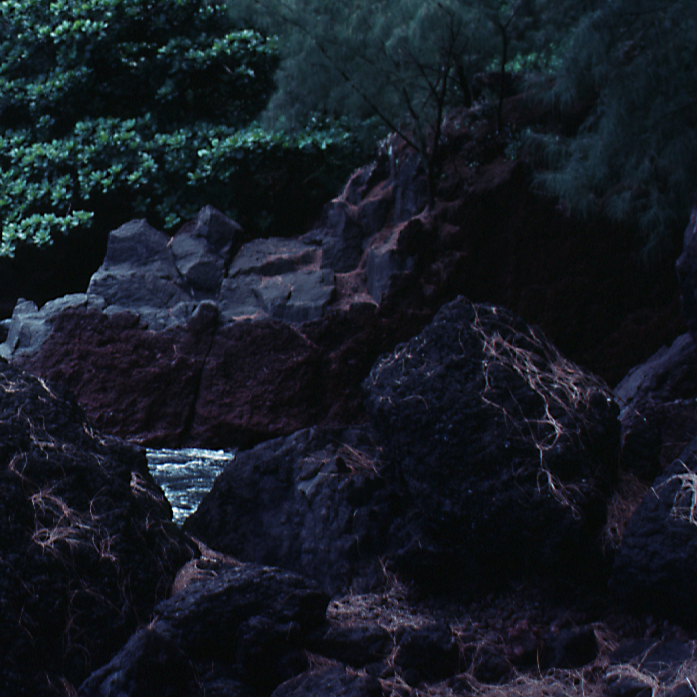

In [ ]:
imagem_original = ski.io.imread(caminho)
imagem_original

In [ ]:
"""Forme um histograma médio a partir dos três histogramas anteriores e use-o como base para obter uma
única função de transformação de intensidade de equalização de histograma. Aplique esta função aos
componentes R, G e B individualmente e converta os resultados para JPG."""

# Calculando os histogramas
hist_r, bins_r = ski.exposure.histogram(imagem_original[:, :, 0], nbins=256, source_range='image')
hist_g, bins_g = ski.exposure.histogram(imagem_original[:, :, 1], nbins=256, source_range='image')
hist_b, bins_b = ski.exposure.histogram(imagem_original[:, :, 2], nbins=256, source_range='image')

hist_r_normalizado = hist_r / np.sum(hist_r)
hist_g_normalizado = hist_g / np.sum(hist_g)
hist_b_normalizado = hist_b / np.sum(hist_b)

hist_medio = (hist_r_normalizado + hist_g_normalizado + hist_b_normalizado) / 3

In [ ]:
#Calculando cdf da média deo histograma
cdf_medio = np.cumsum(hist_medio)

#Escalando CDF
transformacao = cdf_medio * 255

# Aplicando a transformação como cópia da original
imagem_equalizada_media = np.zeros_like(imagem_original, dtype=np.uint8) # Use original image shape and dtype
for i in range(3):
    imagem_equalizada_media[:, :, i] = transformacao[imagem_original[:, :, i].astype(int)]

# Converter a imagem para jpg
ski.io.imsave("/content/drive/MyDrive/processamento de imagens/ep2-tarefa1-proc-imgs/FIG063_3_equalizado_medio.jpg", imagem_equalizada_media)

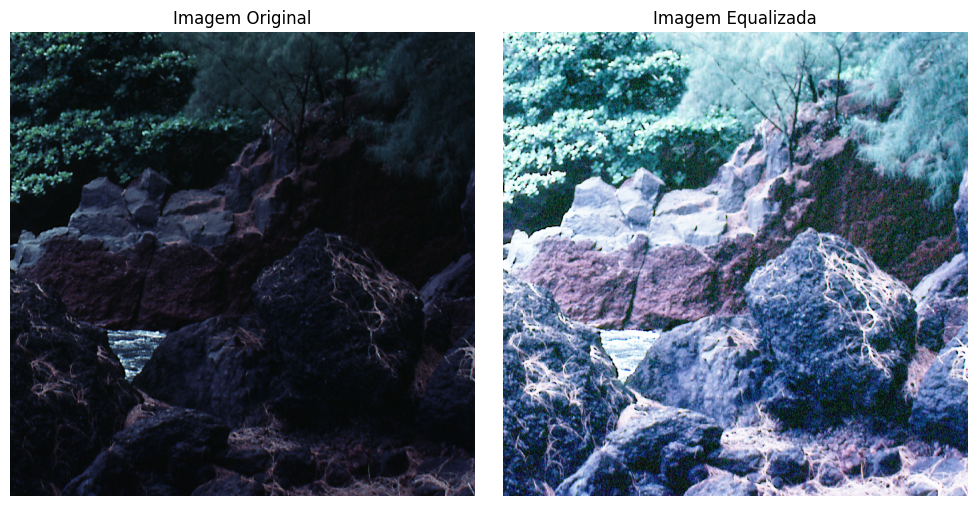

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ski.io.imread(caminho))
axes[0].set_title('Imagem Original')
axes[1].imshow(imagem_equalizada_media)
axes[1].set_title('Imagem Equalizada')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

#Usando minhas imagens
A partir do resultado otido utilize da técnica desta tarefa com uma ou mais imagens da sua base de dados.
A partir de uma análise comparativa, conclua sobre os resultados obtidos.

array([[[137, 136, 131],
        [135, 134, 129],
        [135, 134, 129],
        ...,
        [163, 159, 150],
        [163, 159, 150],
        [163, 159, 150]],

       [[137, 136, 131],
        [135, 134, 129],
        [135, 134, 129],
        ...,
        [164, 160, 151],
        [163, 159, 150],
        [163, 159, 150]],

       [[136, 135, 130],
        [135, 134, 129],
        [134, 133, 128],
        ...,
        [164, 160, 151],
        [163, 159, 150],
        [163, 159, 150]],

       ...,

       [[224, 203, 202],
        [223, 202, 201],
        [222, 201, 200],
        ...,
        [126, 131, 125],
        [126, 131, 125],
        [126, 131, 125]],

       [[223, 202, 201],
        [222, 201, 198],
        [221, 200, 197],
        ...,
        [126, 131, 125],
        [126, 131, 125],
        [126, 131, 125]],

       [[224, 200, 198],
        [224, 200, 198],
        [221, 200, 197],
        ...,
        [127, 132, 126],
        [127, 132, 126],
        [127, 132, 126]]], dtype=uint8)
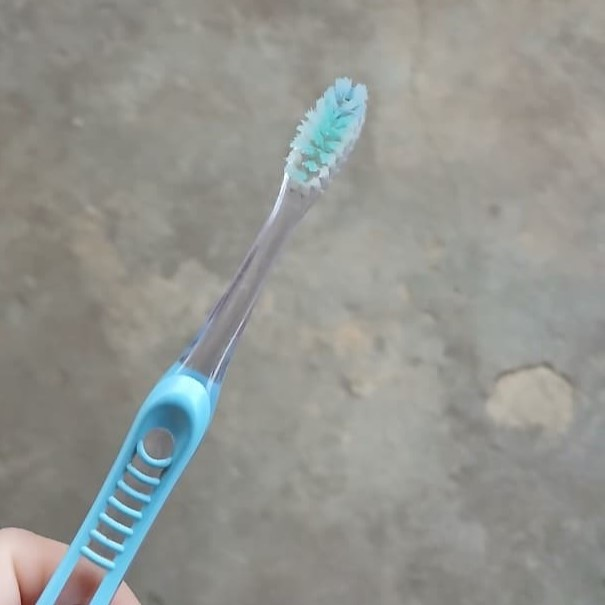

In [ ]:
imagem2 = ski.io.imread("/content/drive/MyDrive/processamento de imagens/ep2-tarefa1-proc-imgs/escova_o_d_sarah.jpg")
imagem2

Refazendo os passos para essa imagem

In [ ]:
hist_r, bins_r = ski.exposure.histogram(imagem2[:, :, 0], nbins=256, source_range='dtype')
hist_g, bins_g = ski.exposure.histogram(imagem2[:, :, 1], nbins=256, source_range='dtype')
hist_b, bins_b = ski.exposure.histogram(imagem2[:, :, 2], nbins=256, source_range='dtype')

hist_r_normalizado = hist_r / hist_r.sum()
hist_g_normalizado = hist_g / hist_g.sum()
hist_b_normalizado = hist_b / hist_b.sum()

hist_medio = (hist_r_normalizado + hist_g_normalizado + hist_b_normalizado) / 3

array([[[ 77,  72,  47],
        [ 66,  61,  39],
        [ 66,  61,  39],
        ...,
        [224, 208, 155],
        [224, 208, 155],
        [224, 208, 155]],

       [[ 77,  72,  47],
        [ 66,  61,  39],
        [ 66,  61,  39],
        ...,
        [227, 213, 161],
        [224, 208, 155],
        [224, 208, 155]],

       [[ 72,  66,  43],
        [ 66,  61,  39],
        [ 61,  56,  35],
        ...,
        [227, 213, 161],
        [224, 208, 155],
        [224, 208, 155]],

       ...,

       [[253, 249, 249],
        [253, 249, 249],
        [253, 249, 249],
        ...,
        [ 28,  47,  25],
        [ 28,  47,  25],
        [ 28,  47,  25]],

       [[253, 249, 249],
        [253, 249, 249],
        [252, 249, 249],
        ...,
        [ 28,  47,  25],
        [ 28,  47,  25],
        [ 28,  47,  25]],

       [[253, 249, 249],
        [253, 249, 249],
        [252, 249, 249],
        ...,
        [ 31,  51,  28],
        [ 31,  51,  28],
        [ 31,  51,  28]]], dtype=uint8)
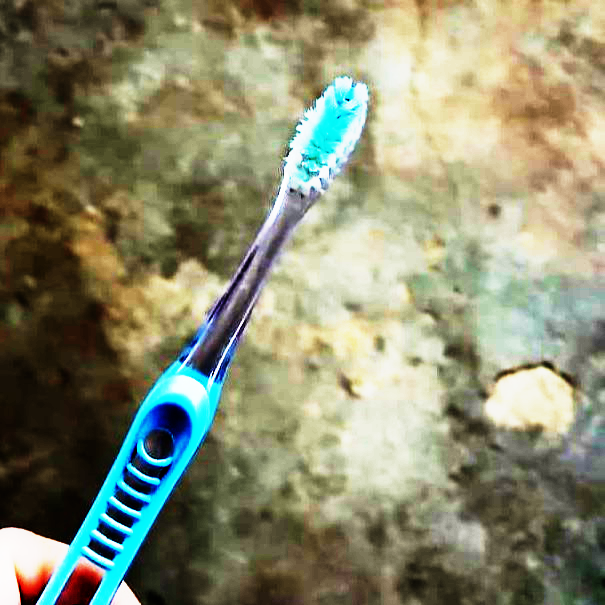

In [ ]:
#Calculando cdf da média deo histograma
cdf_medio = np.cumsum(hist_medio)

#Escalando CDF
transformacao = cdf_medio * 255

# Aplicando a transformação como cópia da original
escova_equalizada_media = np.zeros_like(imagem2, dtype=np.uint8)
for i in range(3):
    escova_equalizada_media[:, :, i] = transformacao[imagem2[:, :, i].astype(int)]

display(escova_equalizada_media)

In [ ]:
# Converter a imagem para jpg
ski.io.imsave("/content/drive/MyDrive/processamento de imagens/ep2-tarefa1-proc-imgs/escova_equalizado_medio.jpg", escova_equalizada_media)

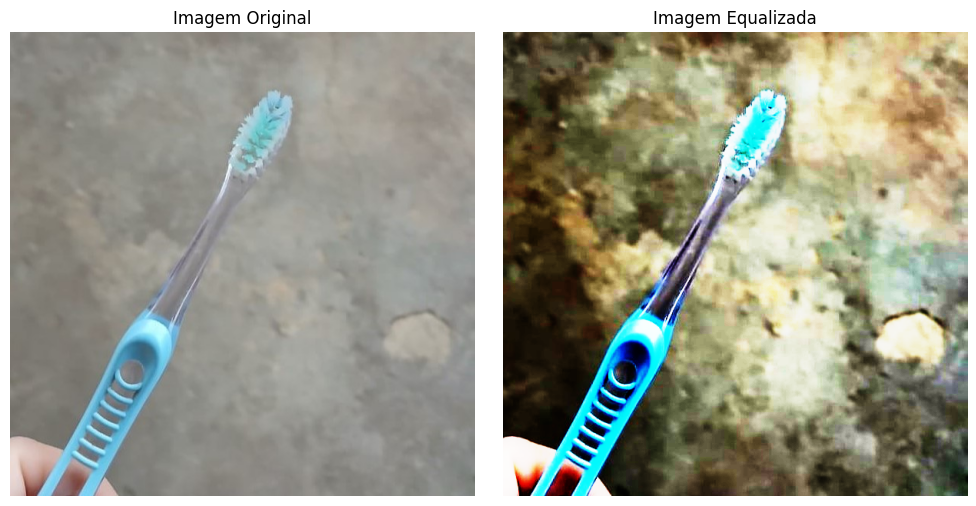

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(imagem2)
axes[0].set_title('Imagem Original')
axes[1].imshow(escova_equalizada_media)
axes[1].set_title('Imagem Equalizada')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()